In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

sns.set_style("whitegrid")

In [89]:
titanic = sns.load_dataset("titanic")

# Task 1: Data Exploration
Load the Titanic dataset from seaborn and get familiar with its structure.

titanic = sns.load_dataset("titanic")
Display the first few rows and inspect the shape of the dataset.
Check data types for each column. Which are numerical? Which are categorical?
Identify missing values — which columns have them, and what percentage of values are missing?
Examine the class balance of the target variable (survived). What is the survival rate?
Create at least two visualizations: one showing the distribution of a numerical feature (e.g., age) and one showing survival rates broken down by a categorical feature (e.g., pclass or sex).

In [92]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [94]:
titanic.shape

(891, 15)

In [96]:
titanic.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [98]:
missing = titanic.isnull().sum()
percent_missing = (missing / len(titanic)) * 100

pd.DataFrame({
    'Missing Values': missing,
    'Percentage': percent_missing
})

,Missing Values,Percentage
survived,0,0.000000
pclass,0,0.000000
sex,0,0.000000
age,177,19.865320
sibsp,0,0.000000
parch,0,0.000000
fare,0,0.000000
embarked,2,0.224467
class,0,0.000000
who,0,0.000000


In [100]:
titanic['survived'].value_counts(normalize=True)

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

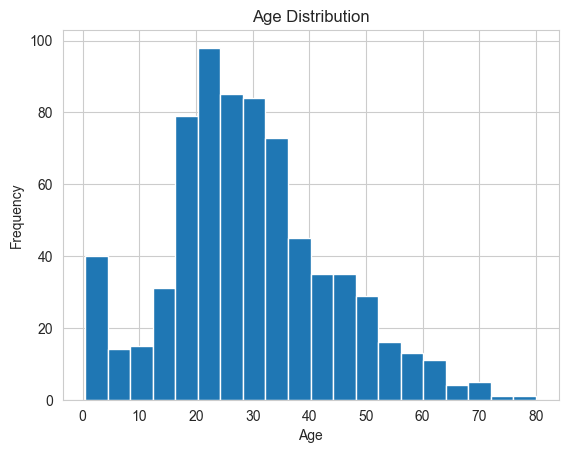

In [102]:
plt.hist(titanic['age'].dropna(), bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

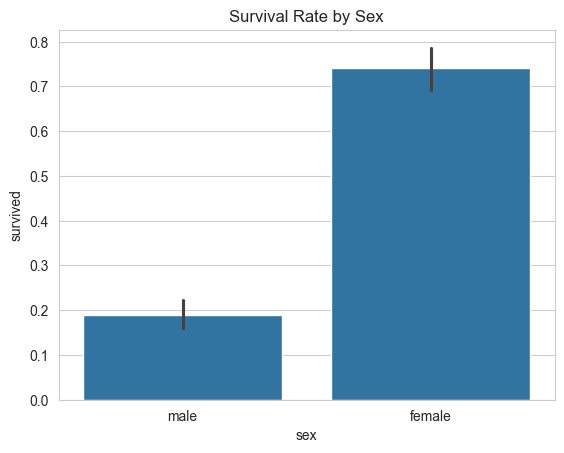

In [104]:
sns.barplot(x='sex', y='survived', data=titanic)
plt.title("Survival Rate by Sex")
plt.show()

# Task 2: Feature Engineering
Transform the raw features into a format suitable for machine learning.

Handle missing values:

Fill missing age values with the median age.
Fill missing embarked values with the mode (most frequent value).
Drop the deck column (too many missing values to be useful).
Encode categorical features:

Apply label encoding to sex (male → 1, female → 0).
Apply one-hot encoding to embarked (creating dummy columns).
Create new features:

family_size = sibsp + parch + 1 (the passenger plus their siblings/spouses and parents/children).
is_alone = 1 if family_size == 1, else 0.
Drop non-numeric and identifier columns that won't be useful for modeling (e.g., alive, who, adult_male, embark_town, class, alone).

Display the final DataFrame and confirm all columns are numeric.

In [107]:
titanic.fillna({'age': titanic['age'].median()}, inplace=True)

In [109]:
titanic.fillna({'embarked': titanic['embarked'].mode()[0]}, inplace=True)

In [111]:
titanic.drop(columns=['deck'], inplace=True)

In [113]:
titanic['sex'] = titanic['sex'].map({'male': 1, 'female': 0})

In [115]:
titanic = pd.get_dummies(titanic, columns=['embarked'], drop_first=True)

In [117]:
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

In [119]:
titanic['is_alone'] = (titanic['family_size'] == 1).astype(int)

In [121]:
titanic.drop(columns=[
    'alive', 'who', 'adult_male', 
    'embark_town', 'class', 'alone'
], inplace=True)

In [123]:
titanic.head()
titanic.dtypes

survived         int64
pclass           int64
sex              int64
age            float64
sibsp            int64
parch            int64
fare           float64
embarked_Q        bool
embarked_S        bool
family_size      int64
is_alone         int64
dtype: object

# Task 3: Feature Scaling & Selection
Apply scaling techniques and identify the most relevant features.

Compare scalers: Apply both StandardScaler and MinMaxScaler to the numeric features. Plot the distributions of age and fare before and after each scaling method (use histograms or KDE plots). In a markdown cell, explain the difference between the two approaches.

Correlation analysis: Compute the correlation matrix for all numeric features. Plot it as a heatmap with annotations. Which features have the strongest positive and negative correlations with survived?

Feature selection: Based on the correlation matrix, select the top features most correlated with the target (absolute correlation ≥ 0.1). List them and briefly justify keeping or dropping borderline features.

In [126]:
df_scaled = titanic.copy()
# Select numeric features (excluding target)
num_cols = df_scaled.drop(columns=['survived']).columns
# StandardScaler
scaler_std = StandardScaler()
df_std = df_scaled.copy()
df_std[num_cols] = scaler_std.fit_transform(df_std[num_cols])
# MinMaxScaler
scaler_mm = MinMaxScaler()
df_mm = df_scaled.copy()
df_mm[num_cols] = scaler_mm.fit_transform(df_mm[num_cols])

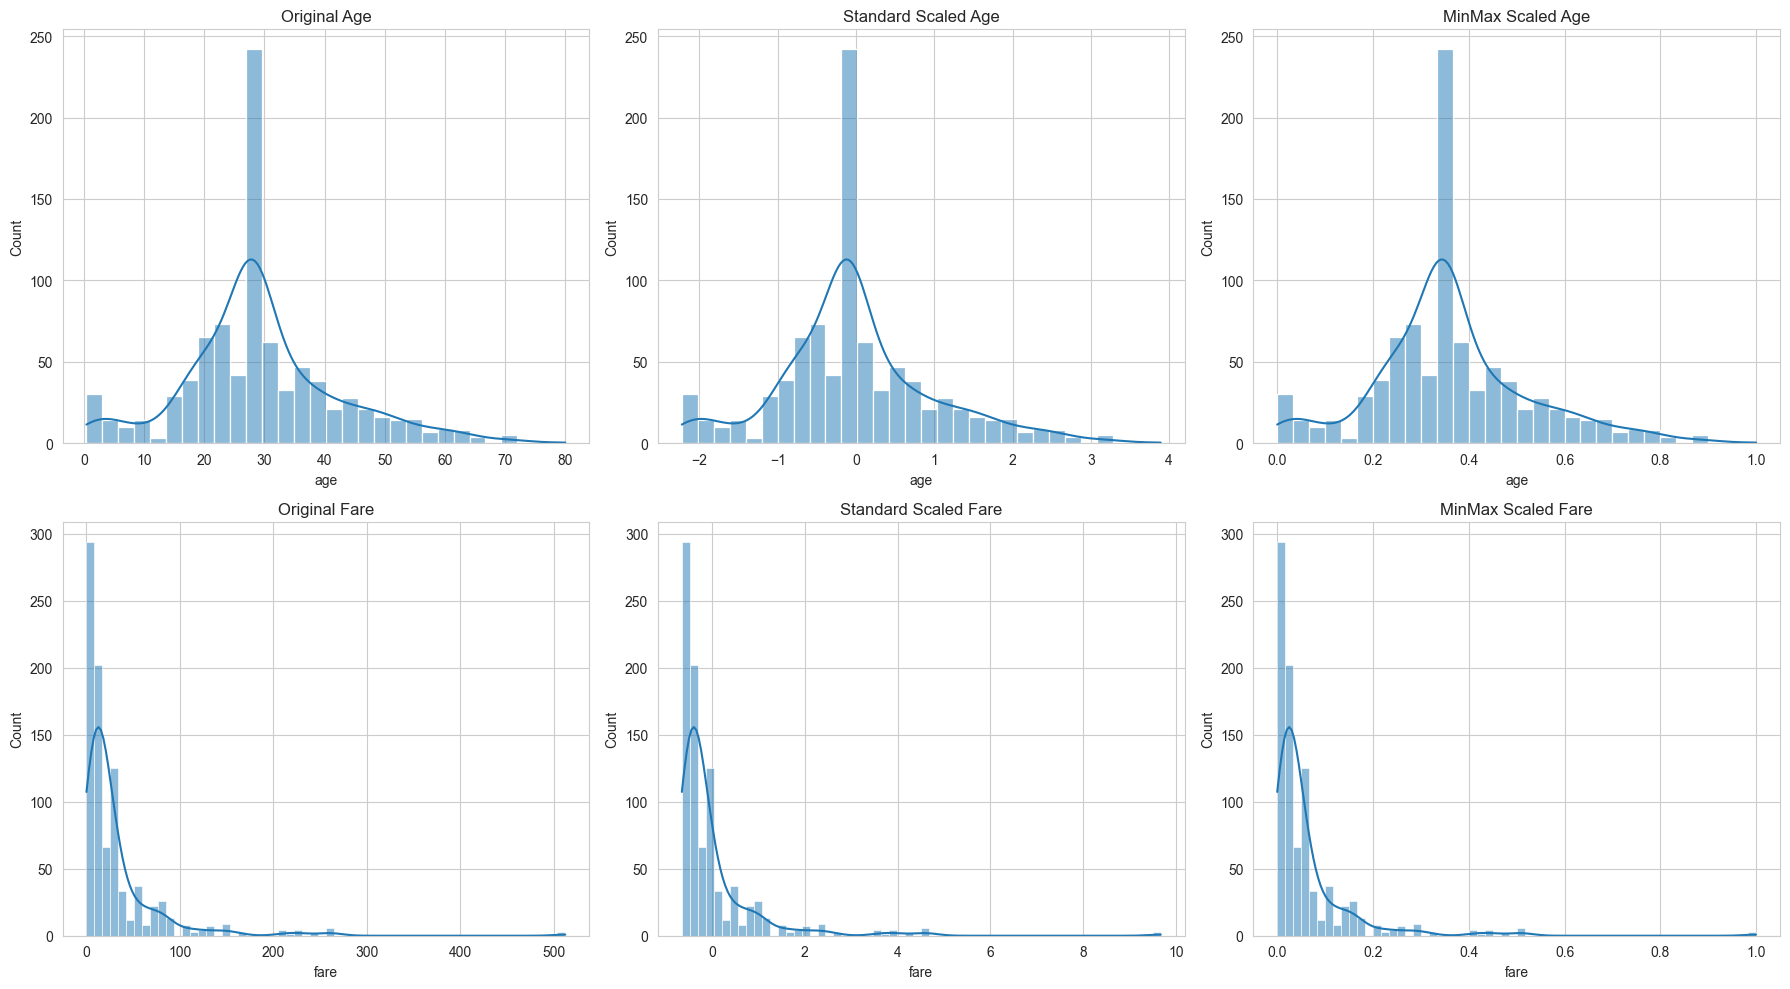

In [128]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# ORIGINAL
sns.histplot(titanic['age'], kde=True, ax=axes[0,0])
axes[0,0].set_title("Original Age")
sns.histplot(titanic['fare'], kde=True, ax=axes[1,0])
axes[1,0].set_title("Original Fare")
# STANDARD
sns.histplot(df_std['age'], kde=True, ax=axes[0,1])
axes[0,1].set_title("Standard Scaled Age")
sns.histplot(df_std['fare'], kde=True, ax=axes[1,1])
axes[1,1].set_title("Standard Scaled Fare")
# MINMAX
sns.histplot(df_mm['age'], kde=True, ax=axes[0,2])
axes[0,2].set_title("MinMax Scaled Age")
sns.histplot(df_mm['fare'], kde=True, ax=axes[1,2])
axes[1,2].set_title("MinMax Scaled Fare")
plt.tight_layout()
plt.show()

From the plots, we can see that both scaling methods keep the overall shape of the distributions the same, but they change the scale in different ways.

With StandardScaler, the values are centered around 0 and spread roughly between negative and positive values. For example, age and fare are no longer in their original units, and we can see values like -2, 0, 2, etc. This means the data is standardized based on its mean and standard deviation.

With MinMaxScaler, all values are transformed into a range between 0 and 1. In the plots, both age and fare are compressed into this interval, so the smallest value becomes 0 and the largest becomes 1.

Another thing I noticed is that for fare, which has strong outliers, MinMaxScaler compresses most values very close to 0, while a few large values stretch toward 1. StandardScaler still shows the skewness, but the spread looks more balanced around 0.

Overall, StandardScaler changes the scale based on distribution, while MinMaxScaler rescales everything into a fixed range.

In [132]:
corr_matrix = titanic.corr()
print(corr_matrix['survived'].sort_values(ascending=False))

survived       1.000000
fare           0.257307
parch          0.081629
family_size    0.016639
embarked_Q     0.003650
sibsp         -0.035322
age           -0.064910
embarked_S    -0.149683
is_alone      -0.203367
pclass        -0.338481
sex           -0.543351
Name: survived, dtype: float64


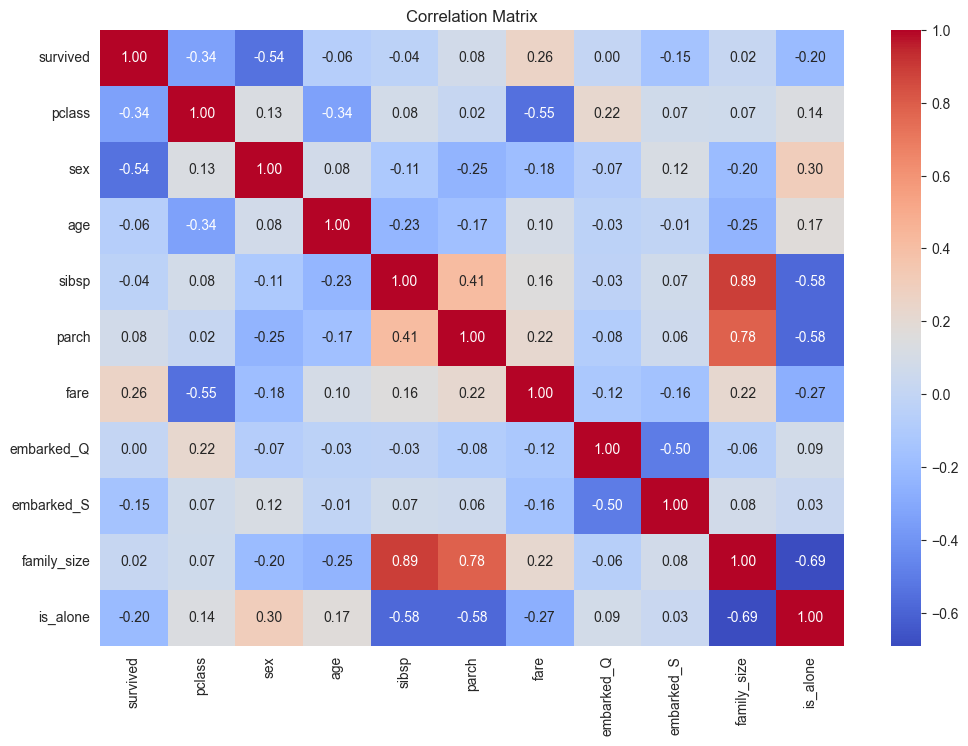

In [134]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

From the correlation matrix, we can see which features are most related to survival.  
The strongest positive correlation with survival is:
*fare (0.26)* → passengers who paid higher fares were more likely to survive  
Other positive correlations are very weak:
parch (0.08) and family_size (0.02) don’t show strong relationships  
The strongest negative correlations are:  
sex (-0.54) → since male = 1 and female = 0, **this means females had a much higher survival rate**  
pclass (-0.34) → passengers in higher classes (1st class) were more likely to survive  
is_alone (-0.20) → people traveling alone were less likely to survive
Some features like:  
age (-0.06)  
sibsp (-0.03)  
embarked_Q (0.00)
show very weak or almost no relationship with survival.  
Overall, the most important factors for survival seem to be *sex, class (pclass), and fare*, while the rest have much smaller effects.

In [137]:
selected_features = corr_target[corr_target >= 0.1].index.tolist()
# remove target
selected_features.remove('survived')
print(selected_features)

['pclass', 'sex', 'fare', 'embarked_S', 'is_alone']


Based on the correlation threshold (|correlation| ≥ 0.1), the selected features are pclass, sex, fare, embarked_S, and is_alone.
Among these, sex has the strongest relationship with survival, followed by pclass and fare, indicating that gender, class, and ticket price were key factors. The feature is_alone is also useful, showing that passengers traveling alone were less likely to survive. Embarked_S has a weaker effect but may still add some information.
Features like age, sibsp, and parch were not selected due to very low correlation, although age could still be useful in some cases.
Overall, the selected features represent the most important factors affecting survival.


# Task 4: Dimensionality Reduction
Apply PCA to explore the dataset in reduced dimensions.

Standardize all numeric features (use StandardScaler — PCA requires standardized data).
Fit PCA with all components. Plot the explained variance ratio for each component as a bar chart, and plot the cumulative explained variance as a line chart. How many components do you need to capture at least 80% of the variance?
Refit PCA with 2 components. Create a scatter plot of the first two principal components, colored by survived. Can you see any separation between survivors and non-survivors?
In a markdown cell, discuss: Does PCA help separate the classes? Would you use PCA as a preprocessing step for this dataset, or is the original feature space sufficient?

In [141]:
# Separate features and target
X = titanic.drop(columns=['survived'])
y = titanic['survived']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [143]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_var = pca.explained_variance_ratio_

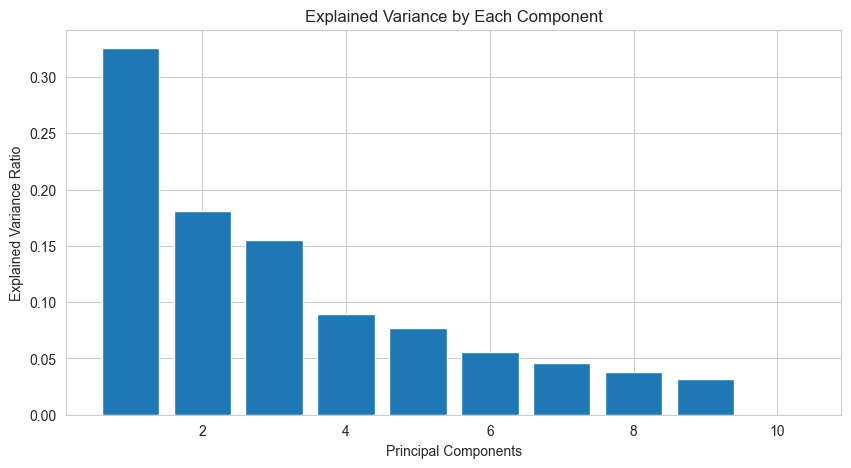

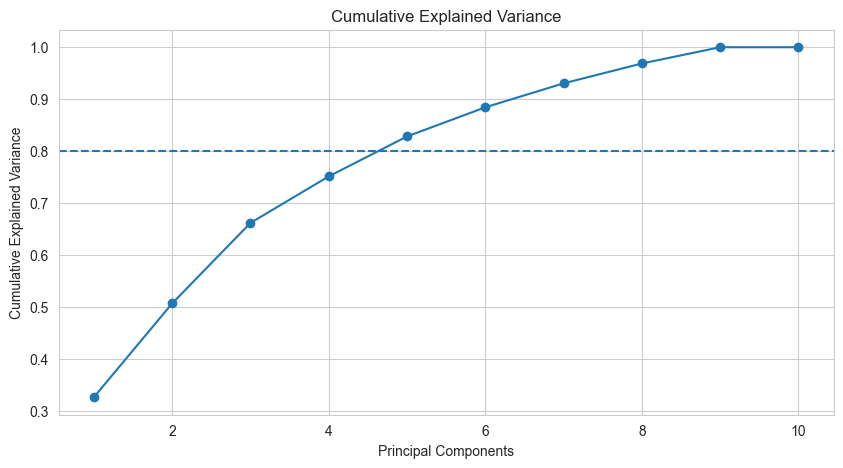

In [145]:
# Bar chart
plt.figure(figsize=(10,5))
plt.bar(range(1, len(explained_var)+1), explained_var)
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Each Component")
plt.show()

# Cumulative line plot
plt.figure(figsize=(10,5))
plt.plot(range(1, len(explained_var)+1), np.cumsum(explained_var), marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.axhline(y=0.8, linestyle='--')
plt.show()

In [147]:
n_components_80 = np.argmax(np.cumsum(explained_var) >= 0.8) + 1
print(n_components_80)

5


In [149]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

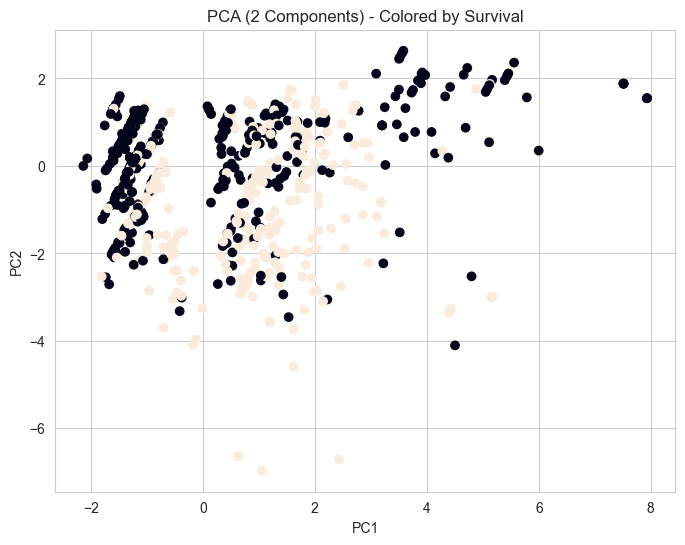

In [151]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2 Components) - Colored by Survival")
plt.show()

### PCA Interpretation

From the explained variance plots, we can see that the first few components capture most of the information. In particular, around **5 components are enough to explain at least 80% of the variance**, as shown by the cumulative curve crossing the 0.8 line.
When reducing the data to 2 components, the scatter plot shows that there is **some slight separation** between survivors and non-survivors, but the points are still heavily overlapping. There is no clear boundary between the two groups.
This suggests that PCA does not strongly separate the classes in this dataset. While it reduces dimensionality and helps visualize the data, it does not make classification easier in this case.
Overall, PCA can be useful for visualization or reducing the number of features, but the original features (such as sex and pclass) already contain strong information. Therefore, using PCA as a preprocessing step is not strictly necessary for this dataset.
